In [45]:
#Importing various libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers , models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [32]:
#load The MNIST dataset
(x_train,y_train),(x_test , y_test) = mnist.load_data()

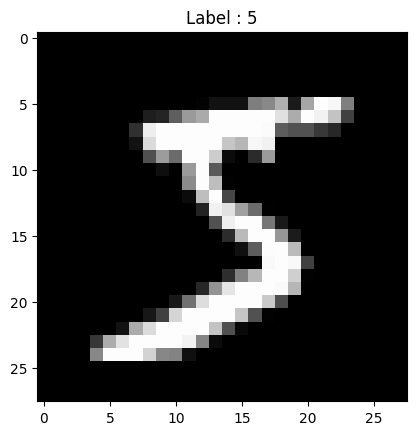

In [33]:
#Visualizing a sample image
plt.imshow(x_train[0] , cmap='gray')
plt.title(f"Label : {y_train[0]}")
plt.show()

In [34]:
#Data Preprocessing
x_train = x_train / 255.0
x_test = x_test / 255.0

#Add channel dimensions (for CNN)
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [46]:
# Stress-Test (Making my model fail)
stress_gen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.25,
    height_shift_range=0.25,
)

stress_gen.fit(x_test)

In [54]:
# Retraining with Augmentation
train_gen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2
)

train_gen.fit(x_train)

In [35]:
#Build the CNN Model
model = models.Sequential()

#First convolution block
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

#Second Convolution Block
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

#Fully Connected Layers
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10 , activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,554 (111.54 KB)

 Trainable params: 28,490 (111.29 KB)

 Non-trainable params: 64 (256.00 B)

In [48]:
# Generate stressed samples
stressed_test = next(stress_gen.flow(
    x_test, y_test ,
    batch_size=len(x_test),
    shuffle=False
))[0]

In [37]:
#Compiling Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [64]:
#Training the model
history = model.fit(
    train_gen.flow(x_train , y_train , batch_size=64),
    epochs = 5,
    validation_data = (x_test , y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 52ms/step - accuracy: 0.9457 - loss: 0.1768 - val_accuracy: 0.9747 - val_loss: 0.0792
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 56ms/step - accuracy: 0.9505 - loss: 0.1621 - val_accuracy: 0.9629 - val_loss: 0.1282
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 54s 58ms/step - accuracy: 0.9478 - loss: 0.1724 - val_accuracy: 0.9773 - val_loss: 0.0720
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 53s 56ms/step - accuracy: 0.9506 - loss: 0.1616 - val_accuracy: 0.9620 - val_loss: 0.1278
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 53s 56ms/step - accuracy: 0.9489 - loss: 0.1666 - val_accuracy: 0.9784 - val_loss: 0.0707


In [66]:
##Evaluating my original model accuracy
stress_loss , stress_acc = model.evaluate(stressed_test , y_test)
print("Stress Test Accuracy : ",stress_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9446 - loss: 0.1778
Stress Test Accuracy :  0.9509999752044678


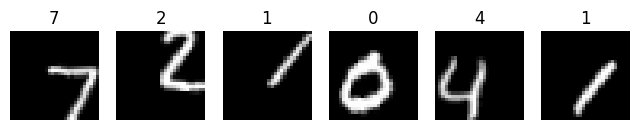

In [61]:
#Visual proof
plt.figure(figsize=(8,3))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(stressed_test[i].reshape(28,28),cmap='gray')
    plt.title(y_test[i])
    plt.axis('off')
plt.show()

In [50]:
#Evaluate on test data
test_loss , test_acc = model.evaluate(x_test , y_test)
print("Test accuracy : ",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9729 - loss: 0.0902
Test accuracy :  0.9776999950408936


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


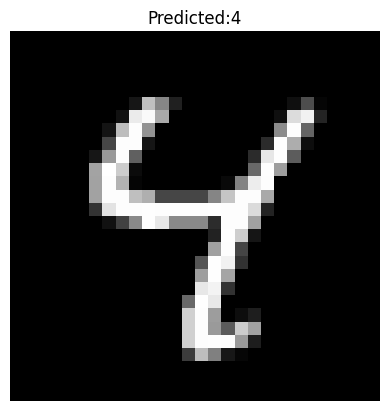

In [43]:
#Making predictions
class_names = [
    "0" , "1" , "2" , "3" , "4" , "5" , "6" , "7" , "8" , "9"
]
predictions = model.predict(x_test)

plt.imshow(x_test[6].reshape(28,28),cmap='gray')
plt.title("Predicted:" + class_names[predictions[6].argmax()])
plt.axis('off')
plt.show()

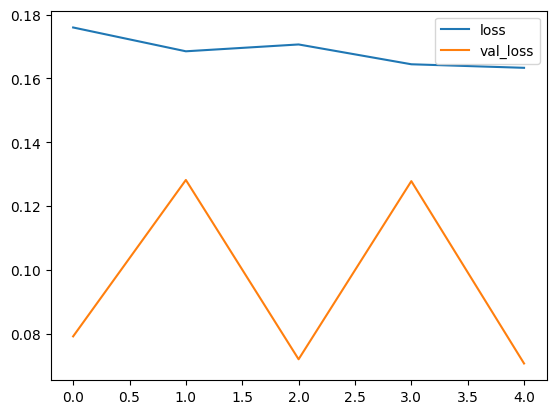

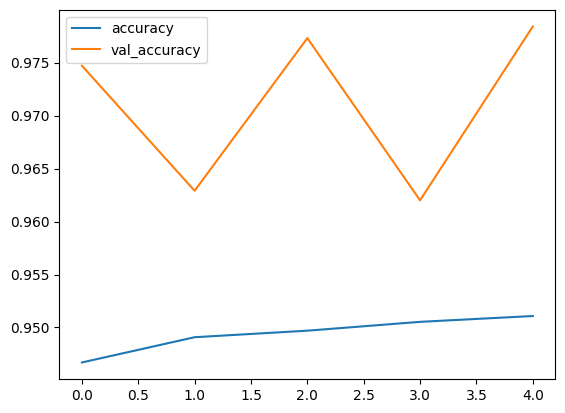

In [67]:
#Visualizing Accuracy
import pandas as pd

history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot();

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


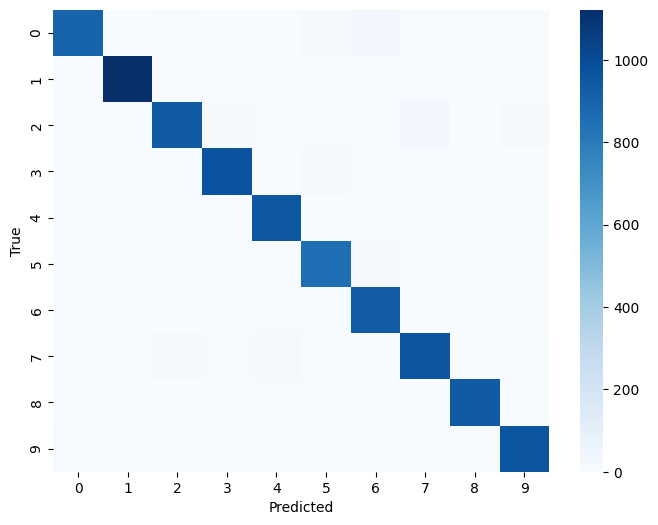

In [68]:
# Failure Ananlysis
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(stressed_test).argmax(axis = 1)
cm = confusion_matrix(y_test , y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm , annot=False , cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()